## Init

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline


from pathlib import Path
import os
os.makedirs('figures', exist_ok=True)

# 设置类型1：探究自变量(通过中介变量)对因变量的影响

## 实验1.1：不同通信算法，不同方案对**性能**(CCT)的影响

### 1.1.1 For AllReduce Algorithms

Improvement from multi to ours: 5.2% - 61.8%
Improvement from one to ours: 30.5% - 71.0%


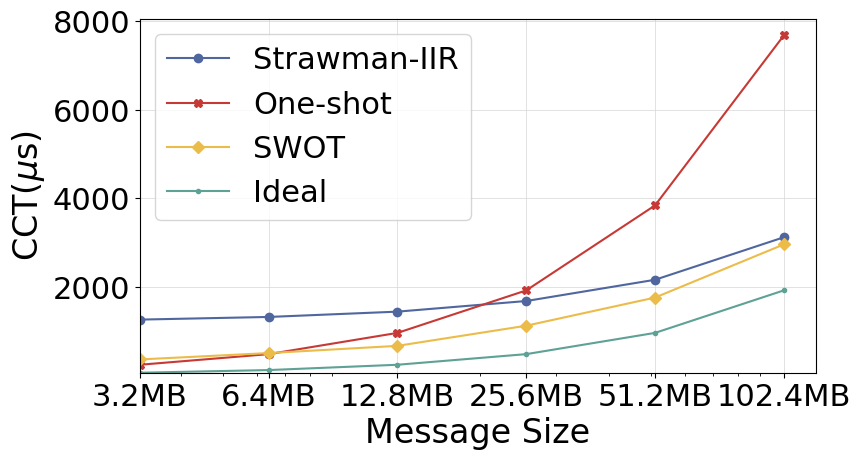

In [ ]:
# Data
message_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096]  # in MiB
message_labels = ['3.2MB', '6.4MB', '12.8MB', '25.6MB', '51.2MB', '102.4MB', '2GiB', '4GiB']
# p=8, k=3
CCT_multi      = [8.56, 9.12, 10.24, 12.48, 16.96, 25.92, 43.84, 79.68]
CCT_one        = [1.68, 3.36, 6.72, 13.44, 26.88, 53.76, 107.52, 215.04]
CCT_ours       = [3.12, 4.16, 5.88, 9.28, 17.11, 27.76, 49.19, 97.33]
# p=16, k=4
CCT_multi      = [12.60, 13.20, 14.40, 16.80, 21.60, 31.20, 50.40, 87.90]
CCT_one        = [2.40, 4.80, 9.60, 19.20, 38.40, 76.80, 153.60, 303.60]
CCT_ours       = [3.60, 5.04, 6.67, 11.22, 17.58, 29.59, 61.28, 120.38]
CCT_ideal      = [0.6, 1.2, 2.4, 4.8, 9.6, 19.2, 38.4, 76.88]

CCT_multi = [x * 100 for x in CCT_multi]
CCT_one   = [x * 100 for x in CCT_one]
CCT_ours = [x * 100 for x in CCT_ours]
CCT_ideal   = [x * 100 for x in CCT_ideal]


# FIXME: 暂时弥补 调度算法中潜在兜底的问题？
for i in range(len(CCT_ours)):
    CCT_ours[i] = min(CCT_ours[i], CCT_multi[i])

# Calculate improvement ratios
multi_to_ours = [(1- ours/multi)*100 for multi,ours in zip(CCT_multi[1:], CCT_ours[1:])]
one_to_ours = [(1 - ours/one)*100 for one,ours in zip(CCT_one[1:], CCT_ours[1:])]
print(f"Improvement from multi to ours: {min([x for x in multi_to_ours if x > 0]):.1f}% - {max(multi_to_ours):.1f}%")
print(f"Improvement from one to ours: {min([x for x in one_to_ours if x > 0]):.1f}% - {max(one_to_ours):.1f}%")


message_sizes  = message_sizes[:-2] 
message_labels  = message_labels[:-2] 
CCT_multi       = CCT_multi[:-2]      
CCT_one         = CCT_one[:-2]        
CCT_ours        = CCT_ours[:-2]       
CCT_ideal       = CCT_ideal[:-2]      


# NOTE: Adjust font sizes according to your paper typesetting!!!
# 1. Set figure size with new aspect ratio (wider)
plt.figure(figsize=(9, 5))
# 2. Set font sizes 
plt.rc('font', size=20)          # controls default text sizes      
plt.rc('axes', labelsize=24)     # fontsize of the x and y labels   | 'Message Size' and 'CCT(ms)' here.
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels      | message_labels here.
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels      | CCT_xxx here.
plt.rc('legend', fontsize=22)    # legend fontsize                  | "Strawman-IIR, One-shot, SWOT, Ideal" here.

# label
plt.xlabel('Message Size')
plt.ylabel('CCT($\mu$s)')

# plot
multi   = plt.plot(message_sizes, CCT_multi,  linestyle='solid', c = '#4f669f', marker = 'o', label='Strawman-IIR')
one     = plt.plot(message_sizes, CCT_one,    linestyle='solid', c = '#c73934', marker = 'X', label='One-shot')
ours    = plt.plot(message_sizes, CCT_ours,   linestyle='solid', c = '#ecbc4a', marker = 'D', label='SWOT')
ideal   = plt.plot(message_sizes, CCT_ideal,  linestyle='solid', c = '#5ea195', marker = '.', label='Ideal')

# decorate
# plt.yscale('log')
plt.xscale('log')

plt.xticks(message_sizes, message_labels)
plt.yticks()
plt.xlim(left=message_sizes[0])
plt.ylim(bottom=min(CCT_multi[0], CCT_one[0], CCT_ours[0], CCT_ideal[0]))

plt.grid(axis='both', which='major',color='#d5d6d5', linewidth=0.5)
plt.legend()

# Adjust layout to prevent clipping
plt.tight_layout()
# save and show
plt.savefig('figures/cct-msgsize_ar-us.pdf')
plt.show()

,message_mib,optimized_cct,baseline_cct,oneshot_cct,ideal_cct,gain_vs_baseline_%
22,0.125,0.2875,1.362344,0.169375,0.162344,78.896662
23,0.500,0.3100,1.369375,0.197500,0.169375,77.361935
24,2.000,0.4000,1.397500,0.310000,0.197500,71.377460
25,8.000,0.6400,1.510000,0.760000,0.310000,57.615894
26,32.000,1.4150,1.960000,2.560000,0.760000,27.806122
27,128.000,3.6400,3.760000,9.760000,2.560000,3.191489


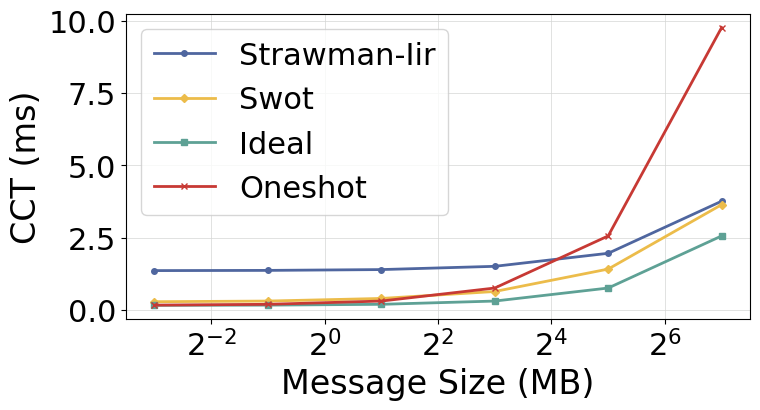

,message_mib,gain_vs_baseline_%
22,0.125,78.896662
23,0.500,77.361935
24,2.000,71.377460
25,8.000,57.615894
26,32.000,27.806122
27,128.000,3.191489


In [ ]:
results_path = Path("../logs/matrix_results-k4_p16_sweep_msg-stride4.csv")
df = pd.read_csv(results_path)

df = df[df["algorithm"] == "ar_having-doubling"].copy()
df = df[df["status"] == "success"].copy()
# ensure numeric and sort
df["message_mib"] = df["message_mib"].astype(float)
df.sort_values("message_mib", inplace=True)

# 根据 message_mib 范围筛选（单位 MiB）
# 将下面的 min_size / max_size 改为你需要的范围；设为 None 表示不设下/上界
min_size = 0.125  # 例如 0.125 MiB
max_size = 128.0  # 例如 128 MiB

mask = np.ones(len(df), dtype=bool)
if min_size is not None:
    mask &= df["message_mib"] >= min_size
if max_size is not None:
    mask &= df["message_mib"] <= max_size

df = df[mask].copy()



df["oneshot_cct"] = df["oneshot_cct"].replace({0: np.nan})
df["gain_vs_baseline_%"] = (1 - df["optimized_cct"] / df["baseline_cct"]) * 100

display(df[["message_mib", "optimized_cct", "baseline_cct", "oneshot_cct", "ideal_cct", "gain_vs_baseline_%"]])

plt.figure(figsize=(8, 4.5))

for label, column, style, color in [
    ("Strawman-IIR", "baseline_cct", "-o", "#4f669f"),
    ("SWOT", "optimized_cct", "-D", "#ecbc4a"),
    ("ideal", "ideal_cct", "-s", "#5ea195"),
    ("oneshot", "oneshot_cct", "-x", "#c73934"),
]:
    plt.plot(
        df["message_mib"],
        df[column],
        style,
        color=color,
        label=label.title(),
        linewidth=2,
        markersize=4,
    )

plt.xscale('log', base=2)
plt.xlabel('Message Size (MB)')
plt.ylabel('CCT (ms)')
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('figures/cct-msgsize_ar_k4p16_measurement.pdf', bbox_inches='tight')
plt.show()

display(df[["message_mib", "gain_vs_baseline_%"]])

---
### 1.1.2 For All-to-all w/ Pairwise Exchange

Improvement from multi to ours: 4.0% - 61.4%
Improvement from one to ours: 25.0% - 71.3%


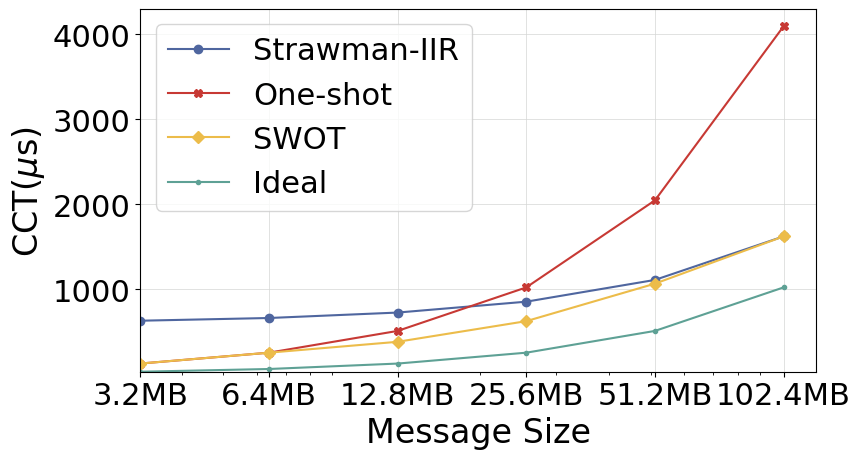

In [ ]:
# Data
message_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096]  # in MiB
message_labels = ['3.2MB', '6.4MB', '12.8MB', '25.6MB', '51.2MB', '102.4MB', '2GiB', '4GiB']
# p=5, k=4
CCT_multi      = [6.32, 6.64, 7.28, 8.56, 11.12, 16.24, 26.48, 46.96]
CCT_one        = [1.28, 2.56, 5.12, 10.24, 20.48, 40.96, 81.92, 163.84]
CCT_ours       = [1.28, 2.56, 3.84, 6.27, 10.68, 22.48, 41.96, 81.40]
CCT_ideal      = [0.32, 0.64, 1.28,  2.56,  5.12,    10.24,  20.48,  40.96]
# p=16, k=4 
# CCT_multi      = [28.32, 28.64, 29.28, 30.56, ]
# CCT_one        = [None, None, None, None, ]
# CCT_ours       = [6.51, 7.02, 8.05, 10.19, ]

CCT_multi = [x * 100 for x in CCT_multi]
CCT_one   = [x * 100 for x in CCT_one]
CCT_ours = [x * 100 for x in CCT_ours]
CCT_ideal   = [x * 100 for x in CCT_ideal]


# FIXME: 暂时弥补 调度算法中潜在兜底的问题？
for i in range(len(CCT_ours)):
    CCT_ours[i] = min(CCT_ours[i], CCT_multi[i])

# Calculate improvement ratios
multi_to_ours = [(1- ours/multi)*100 for multi,ours in zip(CCT_multi[1:], CCT_ours[1:])]
one_to_ours = [(1 - ours/one)*100 for one,ours in zip(CCT_one[1:], CCT_ours[1:])]
print(f"Improvement from multi to ours: {min([x for x in multi_to_ours if x > 0]):.1f}% - {max(multi_to_ours):.1f}%")
print(f"Improvement from one to ours: {min([x for x in one_to_ours if x > 0]):.1f}% - {max(one_to_ours):.1f}%")

message_sizes  = message_sizes[:-2] 
message_labels  = message_labels[:-2] 
CCT_multi       = CCT_multi[:-2]      
CCT_one         = CCT_one[:-2]        
CCT_ours        = CCT_ours[:-2]       
CCT_ideal       = CCT_ideal[:-2]      

# NOTE: Adjust font sizes according to your paper typesetting!!!
# 1. Set figure size with new aspect ratio (wider)
plt.figure(figsize=(9, 5))
# 2. Set font sizes 
plt.rc('font', size=20)          # controls default text sizes      
plt.rc('axes', labelsize=24)     # fontsize of the x and y labels   | 'Message Size' and 'CCT(ms)' here.
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels      | message_labels here.
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels      | CCT_xxx here.
plt.rc('legend', fontsize=22)    # legend fontsize                  | "Strawman-IIR, One-shot, SWOT, Ideal" here.

# label
plt.xlabel('Message Size')
plt.ylabel('CCT($\mu$s)')

# plot
multi   = plt.plot(message_sizes, CCT_multi,  linestyle='solid', c = '#4f669f', marker = 'o', label='Strawman-IIR')
one     = plt.plot(message_sizes, CCT_one,    linestyle='solid', c = '#c73934', marker = 'X', label='One-shot')
ours    = plt.plot(message_sizes, CCT_ours,   linestyle='solid', c = '#ecbc4a', marker = 'D', label='SWOT')
ideal   = plt.plot(message_sizes, CCT_ideal,  linestyle='solid', c = '#5ea195', marker = '.', label='Ideal')

# decorate
# plt.yscale('log')
plt.xscale('log')

plt.xticks(message_sizes, message_labels)
plt.xlim(left=message_sizes[0])
# plt.ylim(bottom=min(CCT_multi[0], CCT_one[0], CCT_ours[0]))
plt.ylim(bottom=min(CCT_multi[0], CCT_one[0], CCT_ours[0], CCT_ideal[0]))

plt.grid(axis='both', which='major',color='#d5d6d5', linewidth=0.5)
plt.legend()

# Adjust layout to prevent clipping
plt.tight_layout()
# save and show
plt.savefig('figures/cct-msgsize_a2a-pair-us.pdf')
plt.show()

,message_mib,optimized_cct,baseline_cct,oneshot_cct,ideal_cct,gain_vs_baseline_%
30,0.125,0.742333,3.10125,NaN,0.30125,76.063415
31,0.500,0.749333,3.10500,NaN,0.30500,75.866881
32,2.000,0.876000,3.12000,NaN,0.32000,71.923077
33,8.000,0.878667,3.18000,NaN,0.38000,72.368972
34,32.000,1.473333,3.42000,NaN,0.62000,56.920079
35,128.000,3.574667,4.38000,NaN,1.58000,18.386605


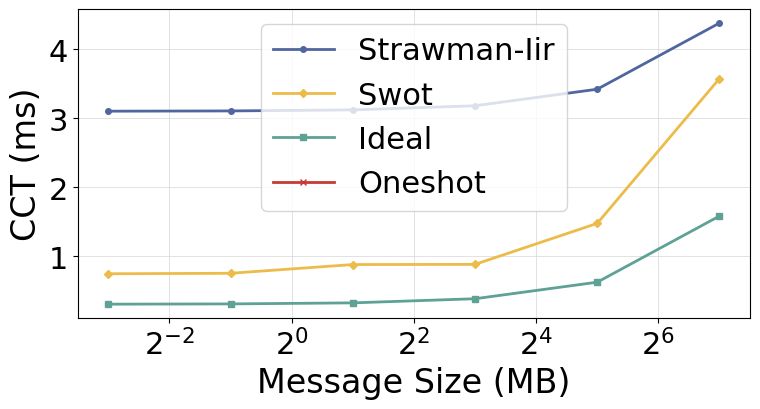

,message_mib,gain_vs_baseline_%
30,0.125,76.063415
31,0.500,75.866881
32,2.000,71.923077
33,8.000,72.368972
34,32.000,56.920079
35,128.000,18.386605


In [ ]:
results_path = Path("../logs/matrix_results-k4_p16_sweep_msg-stride4.csv")
df = pd.read_csv(results_path)

df = df[df["algorithm"] == "a2a_pairwise"].copy()
df = df[df["status"] == "success"].copy()
# ensure numeric and sort
df["message_mib"] = df["message_mib"].astype(float)
df.sort_values("message_mib", inplace=True)

# 根据 message_mib 范围筛选（单位 MiB）
# 将下面的 min_size / max_size 改为你需要的范围；设为 None 表示不设下/上界
min_size = 0.125  # 例如 0.125 MiB
max_size = 128.0  # 例如 128 MiB

mask = np.ones(len(df), dtype=bool)
if min_size is not None:
    mask &= df["message_mib"] >= min_size
if max_size is not None:
    mask &= df["message_mib"] <= max_size

df = df[mask].copy()



df["oneshot_cct"] = df["oneshot_cct"].replace({0: np.nan})
df["gain_vs_baseline_%"] = (1 - df["optimized_cct"] / df["baseline_cct"]) * 100

display(df[["message_mib", "optimized_cct", "baseline_cct", "oneshot_cct", "ideal_cct", "gain_vs_baseline_%"]])

plt.figure(figsize=(8, 4.5))

for label, column, style, color in [
    ("Strawman-IIR", "baseline_cct", "-o", "#4f669f"),
    ("SWOT", "optimized_cct", "-D", "#ecbc4a"),
    ("ideal", "ideal_cct", "-s", "#5ea195"),
    ("oneshot", "oneshot_cct", "-x", "#c73934"),
]:
    plt.plot(
        df["message_mib"],
        df[column],
        style,
        color=color,
        label=label.title(),
        linewidth=2,
        markersize=4,
    )

plt.xscale('log', base=2)
plt.xlabel('Message Size (MB)')
plt.ylabel('CCT (ms)')
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('figures/cct-msgsize_a2a_bruck_k4p16_measurement.pdf', bbox_inches='tight')
plt.show()

display(df[["message_mib", "gain_vs_baseline_%"]])

---
### 1.1.3 For All-to-all (Bruck)

Improvement from multi to ours: 4.0% - 26.8%
Improvement from one to ours: 38.8% - 74.1%


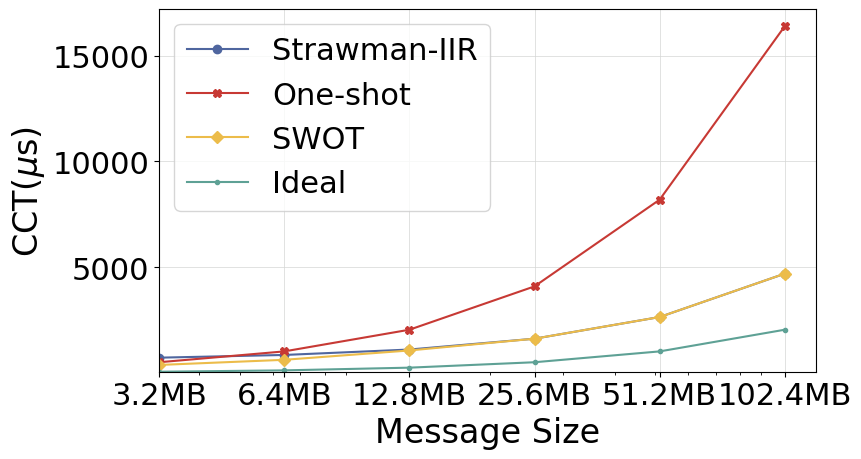

In [22]:
# Data
message_sizes = [32, 64, 128, 256, 512, 1024, 2048, 4096]  # in MiB
message_labels = ['3.2MB', '6.4MB', '12.8MB', '25.6MB', '51.2MB', '102.4MB', '2GiB', '4GiB']

# p=4, k=16
CCT_multi      = [7.28, 8.56, 11.12, 16.24, 26.48, 46.96, 87.92, 169.84]
CCT_one        = [5.12, 10.24, 20.48, 40.96, 81.92, 163.84, 327.68, 655.36]
CCT_ours       = [3.84, 6.27, 10.68, 22.48, 41.96, 79.09, 247.76, 329.68]
CCT_ideal      = [0.64, 1.28, 2.56, 5.12, 10.24, 20.48, 40.96, 81.92]

CCT_multi = [x * 100 for x in CCT_multi]
CCT_one   = [x * 100 for x in CCT_one]
CCT_ours = [x * 100 for x in CCT_ours]
CCT_ideal   = [x * 100 for x in CCT_ideal]


# FIXME: 暂时弥补 调度算法中潜在兜底的问题？
for i in range(len(CCT_ours)):
    CCT_ours[i] = min(CCT_ours[i], CCT_multi[i])

# Calculate improvement ratios
multi_to_ours = [(1- ours/multi)*100 for multi,ours in zip(CCT_multi[1:], CCT_ours[1:])]
one_to_ours = [(1 - ours/one)*100 for one,ours in zip(CCT_one[1:], CCT_ours[1:])]
print(f"Improvement from multi to ours: {min([x for x in multi_to_ours if x > 0]):.1f}% - {max(multi_to_ours):.1f}%")
print(f"Improvement from one to ours: {min([x for x in one_to_ours if x > 0]):.1f}% - {max(one_to_ours):.1f}%")

message_sizes  = message_sizes[:-2] 
message_labels  = message_labels[:-2] 
CCT_multi       = CCT_multi[:-2]      
CCT_one         = CCT_one[:-2]        
CCT_ours        = CCT_ours[:-2]    
CCT_ideal       = CCT_ideal[:-2]         

# NOTE: Adjust font sizes according to your paper typesetting!!!
# 1. Set figure size with new aspect ratio (wider)
plt.figure(figsize=(9, 5))
# 2. Set font sizes 
plt.rc('font', size=20)          # controls default text sizes      
plt.rc('axes', labelsize=24)     # fontsize of the x and y labels   | 'Message Size' and 'CCT(ms)' here.
plt.rc('xtick', labelsize=22)    # fontsize of the tick labels      | message_labels here.
plt.rc('ytick', labelsize=22)    # fontsize of the tick labels      | CCT_xxx here.
plt.rc('legend', fontsize=22)    # legend fontsize                  | "Strawman-IIR, One-shot, SWOT, Ideal" here.

# label
plt.xlabel('Message Size', fontsize=24)
plt.ylabel('CCT($\mu$s)')

# plot
multi   = plt.plot(message_sizes, CCT_multi,  linestyle='solid', c = '#4f669f', marker = 'o', label='Strawman-IIR')
one     = plt.plot(message_sizes, CCT_one,    linestyle='solid', c = '#c73934', marker = 'X', label='One-shot')
ours    = plt.plot(message_sizes, CCT_ours,   linestyle='solid', c = '#ecbc4a', marker = 'D', label='SWOT')
ideal   = plt.plot(message_sizes, CCT_ideal,  linestyle='solid', c = '#5ea195', marker = '.', label='Ideal')


# decorate
# plt.yscale('log')
plt.xscale('log')

plt.xticks(message_sizes, message_labels)
plt.xlim(left=message_sizes[0])
# plt.ylim(bottom=min(CCT_multi[0], CCT_one[0], CCT_ours[0]))
plt.ylim(bottom=min(CCT_multi[0], CCT_one[0], CCT_ours[0], CCT_ideal[0]))

plt.grid(axis='both', which='major',color='#d5d6d5', linewidth=0.5)
plt.legend(fontsize=22)

# Adjust layout to prevent clipping
plt.tight_layout()
# save and show
plt.savefig('cct-msgsize_a2a_bruck-us.pdf')
plt.show()

,message_mib,optimized_cct,baseline_cct,oneshot_cct,ideal_cct,gain_vs_baseline_%
22,0.125,0.2875,1.362344,0.169375,0.162344,78.896662
23,0.500,0.3100,1.369375,0.197500,0.169375,77.361935
24,2.000,0.4000,1.397500,0.310000,0.197500,71.377460
25,8.000,0.6400,1.510000,0.760000,0.310000,57.615894
26,32.000,1.4150,1.960000,2.560000,0.760000,27.806122
27,128.000,3.6400,3.760000,9.760000,2.560000,3.191489


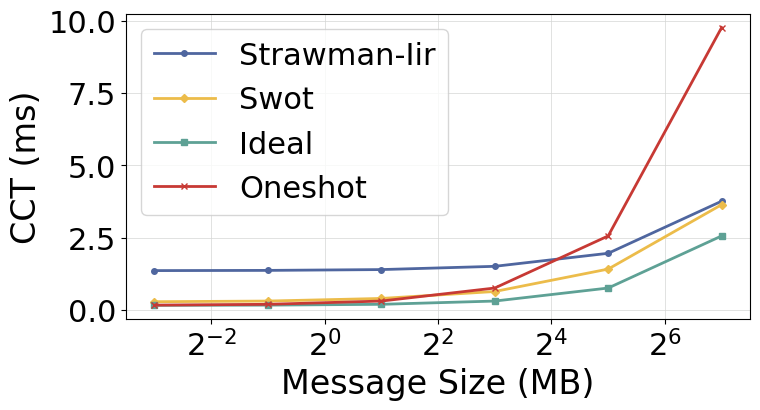

,message_mib,gain_vs_baseline_%
22,0.125,78.896662
23,0.500,77.361935
24,2.000,71.377460
25,8.000,57.615894
26,32.000,27.806122
27,128.000,3.191489


In [ ]:
results_path = Path("../logs/matrix_results-k4_p16_sweep_msg-stride4.csv")
df = pd.read_csv(results_path)

df = df[df["algorithm"] == "ar_having-doubling"].copy()
df = df[df["status"] == "success"].copy()
# ensure numeric and sort
df["message_mib"] = df["message_mib"].astype(float)
df.sort_values("message_mib", inplace=True)

# 根据 message_mib 范围筛选（单位 MiB）
# 将下面的 min_size / max_size 改为你需要的范围；设为 None 表示不设下/上界
min_size = 0.125  # 例如 0.125 MiB
max_size = 128.0  # 例如 128 MiB

mask = np.ones(len(df), dtype=bool)
if min_size is not None:
    mask &= df["message_mib"] >= min_size
if max_size is not None:
    mask &= df["message_mib"] <= max_size

df = df[mask].copy()



df["oneshot_cct"] = df["oneshot_cct"].replace({0: np.nan})
df["gain_vs_baseline_%"] = (1 - df["optimized_cct"] / df["baseline_cct"]) * 100

display(df[["message_mib", "optimized_cct", "baseline_cct", "oneshot_cct", "ideal_cct", "gain_vs_baseline_%"]])

plt.figure(figsize=(8, 4.5))

for label, column, style, color in [
    ("Strawman-IIR", "baseline_cct", "-o", "#4f669f"),
    ("SWOT", "optimized_cct", "-D", "#ecbc4a"),
    ("ideal", "ideal_cct", "-s", "#5ea195"),
    ("oneshot", "oneshot_cct", "-x", "#c73934"),
]:
    plt.plot(
        df["message_mib"],
        df[column],
        style,
        color=color,
        label=label.title(),
        linewidth=2,
        markersize=4,
    )

plt.xscale('log', base=2)
plt.xlabel('Message Size (MB)')
plt.ylabel('CCT (ms)')
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('figures/cct-msgsize_a2a_bruck_k4p16_measurement.pdf', bbox_inches='tight')
plt.show()

display(df[["message_mib", "gain_vs_baseline_%"]])

## 实验 1.2：不同通信算法，不同方案对**可扩展性**的影响

---
### 1.2.1 AllReduce

Improvement from multi to ours: 14.5% - 35.2%


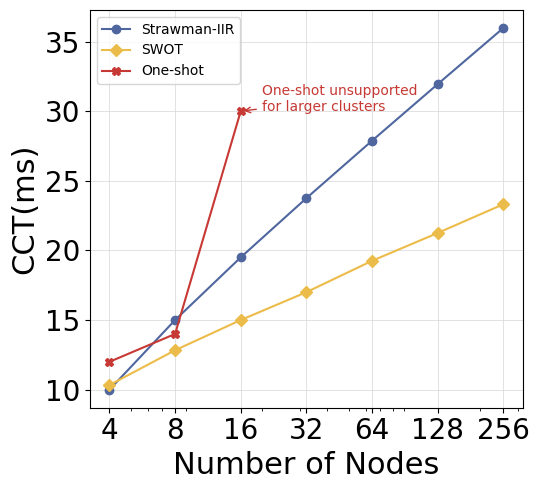

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# k = 4
# params['m'] = 400 * 1024 * 1024  # 总消息大小，400MB，转换为字节
num_gpus =   [4, 8, 16, 32, 64, 128, 256]
gpu_labels = ['4', '8', '16', '32', '64', '128', '256']

# CCT_multi      = [10.00, 15.00, 19.50, 23.75]
# CCT_one        = [12.00, 14.00, 30.00, None]
# CCT_ours       = [10.33, 12.83, 15.00, 16]

CCT_multi      = [10.00, 15.00, 19.50, 23.75, 27.875, 31.938, 35.969]
CCT_one        = [12.00, 14.00, 30.00, None, None, None, None]
CCT_ours       = [10.33, 12.83, 15.00, 17, 19.25, 21.250, 23.313]
CCT_ideal      = [6.00, 7.00, 7.50, 7.75, 7.88, 7.94, 7.97]

# Calculate improvement ratios
multi_to_ours = [(1- ours/multi)*100 for multi,ours in zip(CCT_multi[1:], CCT_ours[1:])]
print(f"Improvement from multi to ours: {min([x for x in multi_to_ours if x > 0]):.1f}% - {max(multi_to_ours):.1f}%")


# 创建有效数据掩码
mask = np.array([x is not None for x in CCT_one])

# NOTE: Adjust font sizes according to your paper typesetting!!!
# 1. Set figure size with new aspect ratio (wider)
plt.figure(figsize=(5.5, 5))
# 2. Set font sizes 
plt.rc('font', size=10)          # controls default text sizes      
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels   | 'Message Size' and 'CCT(ms)' here.
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels      | message_labels here.
plt.rc('ytick', labelsize=20)    # fontsize of the tick labels      | CCT_xxx here.
plt.rc('legend', fontsize=10)    # legend fontsize                  | "Strawman-IIR, One-shot, SWOT, Ideal" here.

# 绘制连接线
plt.plot(num_gpus, CCT_multi, linestyle='solid', c='#4f669f', marker='o', label='Strawman-IIR')
plt.plot(num_gpus, CCT_ours, linestyle='solid', c='#ecbc4a', marker='D', label='SWOT')
# plt.legend(prop={'size': 6})  # 添加prop参数控制图注大小

# One-shot只绘制前3个点
plt.plot(np.array(num_gpus)[mask], np.array(CCT_one)[mask], 
         linestyle='solid', c='#c73934', marker='X', label='One-shot')

# 添加不支持的标注
plt.annotate('One-shot unsupported\nfor larger clusters', 
             xy=(16,30), xytext=(20, 30),
             arrowprops=dict(arrowstyle="->", color='#c73934', linewidth=1),
             color='#c73934', fontsize=10)

# 格式设置
plt.xlabel('Number of Nodes')
plt.ylabel('CCT(ms)')
plt.xscale('log')
plt.xticks(num_gpus, gpu_labels)
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

# 显示关键转折点
# plt.axvline(x=4, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
# plt.text(4.5, 300, 'Cross Point', rotation=90, color='grey', fontsize=9)

# Adjust layout to prevent clipping
plt.tight_layout()

plt.legend()
plt.savefig('cct-scale_ar-us.pdf', bbox_inches='tight')
plt.show()

---
### 1.2.2 All-to-all Pair

Improvement from multi to ours: 20.0% - 42.6%


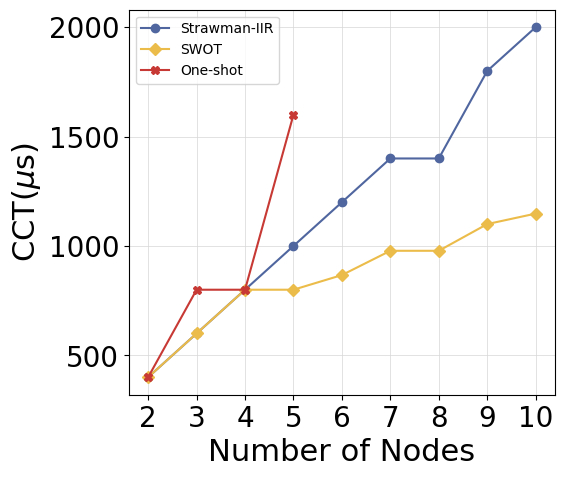

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# k = 4
# params['m'] = 400 * 1024 * 1024  # 总消息大小，400MB，转换为字节
num_gpus =   [ 2,   3,   4,   5,   6,   7,   8, 9, 10]
gpu_labels = ['2', '3', '4', '5', '6', '7', '8', '9', '10']

# CCT_multi      = [10.00, 15.00, 19.50, 23.75]
# CCT_one        = [12.00, 14.00, 30.00, None]
# CCT_ours       = [10.33, 12.83, 15.00, 16]

CCT_multi      = [4.00, 6.00,   8.00, 10.00, 12.00, 14.00, 14.00, 18.00, 20.00]
CCT_one        = [4.00, 8.00,   8.00, 16.00, None, None, None, None, None]
CCT_ours       = [16.00, 16.00, 18.00, 8.00, 8.67, 9.78, 9.78, 11.00, 11.48]
for i in range(len(CCT_ours)):
    CCT_ours[i] = min(CCT_ours[i], CCT_multi[i])

CCT_multi = [x * 100 if x is not None else None for x in CCT_multi]
CCT_one   = [x * 100 if x is not None else None for x in CCT_one]
CCT_ours = [x * 100 if x is not None else None for x in CCT_ours]


# Calculate improvement ratios
multi_to_ours = [(1- ours/multi)*100 for multi,ours in zip(CCT_multi[1:], CCT_ours[1:])]
print(f"Improvement from multi to ours: {min([x for x in multi_to_ours if x > 0]):.1f}% - {max(multi_to_ours):.1f}%")

# 创建有效数据掩码
mask = np.array([x is not None for x in CCT_one])

# NOTE: Adjust font sizes according to your paper typesetting!!!
# 1. Set figure size with new aspect ratio (wider)
plt.figure(figsize=(5.5, 5))
# 2. Set font sizes 
plt.rc('font', size=10)          # controls default text sizes
plt.rc('axes', titlesize=22)     # fontsize of the axes title
plt.rc('axes', labelsize=22)     # fontsize of the x and y labels
plt.rc('xtick', labelsize=20)    # fontsize of the tick labels
plt.rc('ytick', labelsize=20)    # fontsize of the tick labels
plt.rc('legend', fontsize=10)    # legend fontsize 左上角


# 绘制连接线
plt.plot(num_gpus, CCT_multi, linestyle='solid', c='#4f669f', marker='o', label='Strawman-IIR')
plt.plot(num_gpus, CCT_ours, linestyle='solid', c='#ecbc4a', marker='D', label='SWOT')

# One-shot只绘制前3个点
plt.plot(np.array(num_gpus)[mask], np.array(CCT_one)[mask], 
         linestyle='solid', c='#c73934', marker='X', label='One-shot')

# 添加不支持的标注
plt.annotate('One-shot unsupported\nfor larger clusters', 
             xy=(5,16), xytext=(5, 18),
             arrowprops=dict(arrowstyle="->", color='#c73934', linewidth=1),
             color='#c73934', fontsize=10)

# 格式设置
plt.xlabel('Number of Nodes')
# plt.ylabel('CCT(ms)')
plt.ylabel('CCT($\mu$s)')
# plt.xscale('log')
plt.xticks(num_gpus, gpu_labels)
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

# 显示关键转折点
# plt.axvline(x=4, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
# plt.text(4.5, 300, 'Cross Point', rotation=90, color='grey', fontsize=9)

plt.legend()
plt.savefig('cct-scale_a2a-pair-us.pdf', bbox_inches='tight')
plt.show()

---
### 1.2.3 All-to-all Bruck

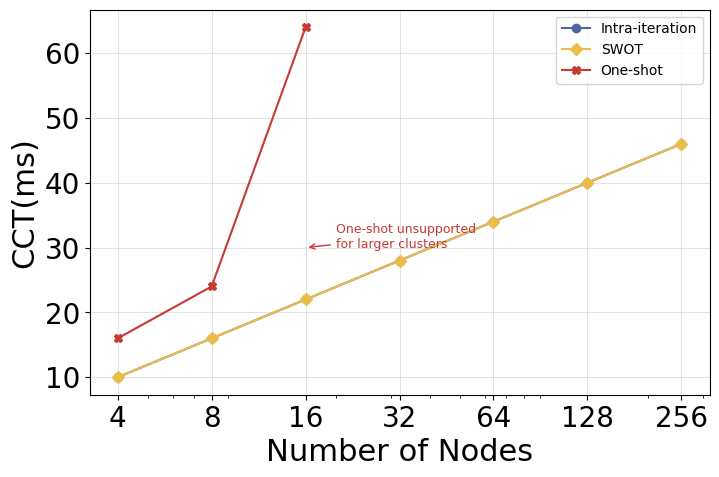

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# k = 4
# params['m'] = 400 * 1024 * 1024  # 总消息大小，400MB，转换为字节
num_gpus =   [4, 8, 16, 32, 64, 128, 256]
gpu_labels = ['4', '8', '16', '32', '64', '128', '256']

# CCT_multi      = [10.00, 15.00, 19.50, 23.75]
# CCT_one        = [12.00, 14.00, 30.00, None]
# CCT_ours       = [10.33, 12.83, 15.00, 16]

CCT_multi      = [10.00, 16.00, 22.00, 28.00, 34.00, 40.00, 46.00]
CCT_one        = [16.00, 24.00, 64.00, None, None, None, None]
CCT_ours       = [32.00, 50.00, 34.00, 34.22, 37.00, 41.83, 49.17]
for i in range(len(CCT_ours)):
    CCT_ours[i] = min(CCT_ours[i], CCT_multi[i])


# Calculate improvement ratios
# multi_to_ours = [(1- ours/multi)*100 for multi,ours in zip(CCT_multi[1:], CCT_ours[1:])]
# print(f"Improvement from multi to ours: {min([x for x in multi_to_ours if x > 0]):.1f}% - {max(multi_to_ours):.1f}%")


# 创建有效数据掩码
mask = np.array([x is not None for x in CCT_one])

plt.figure(figsize=(8, 5))

# 绘制连接线
plt.plot(num_gpus, CCT_multi, linestyle='solid', c='#4f669f', marker='o', label='Intra-iteration')
plt.plot(num_gpus, CCT_ours, linestyle='solid', c='#ecbc4a', marker='D', label='SWOT')

# One-shot只绘制前3个点
plt.plot(np.array(num_gpus)[mask], np.array(CCT_one)[mask], 
         linestyle='solid', c='#c73934', marker='X', label='One-shot')

# 添加不支持的标注
plt.annotate('One-shot unsupported\nfor larger clusters', 
             xy=(16,30), xytext=(20, 30),
             arrowprops=dict(arrowstyle="->", color='#c73934', linewidth=1),
             color='#c73934', fontsize=9)

# 格式设置
plt.xlabel('Number of Nodes')
plt.ylabel('CCT(ms)')
plt.xscale('log')
plt.xticks(num_gpus, gpu_labels)
plt.grid(axis='both', which='major', color='#d5d6d5', linewidth=0.5)

# 显示关键转折点
# plt.axvline(x=4, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)
# plt.text(4.5, 300, 'Cross Point', rotation=90, color='grey', fontsize=9)

plt.legend()
plt.savefig('scale-cct-a2a-bruck.pdf', bbox_inches='tight')
plt.show()

---
# 设置类型2：探究调节变量对“自变量作用于因变量”的基本影响

## 实验2.1：不同OCS数量对方案(作用于DV)的影响

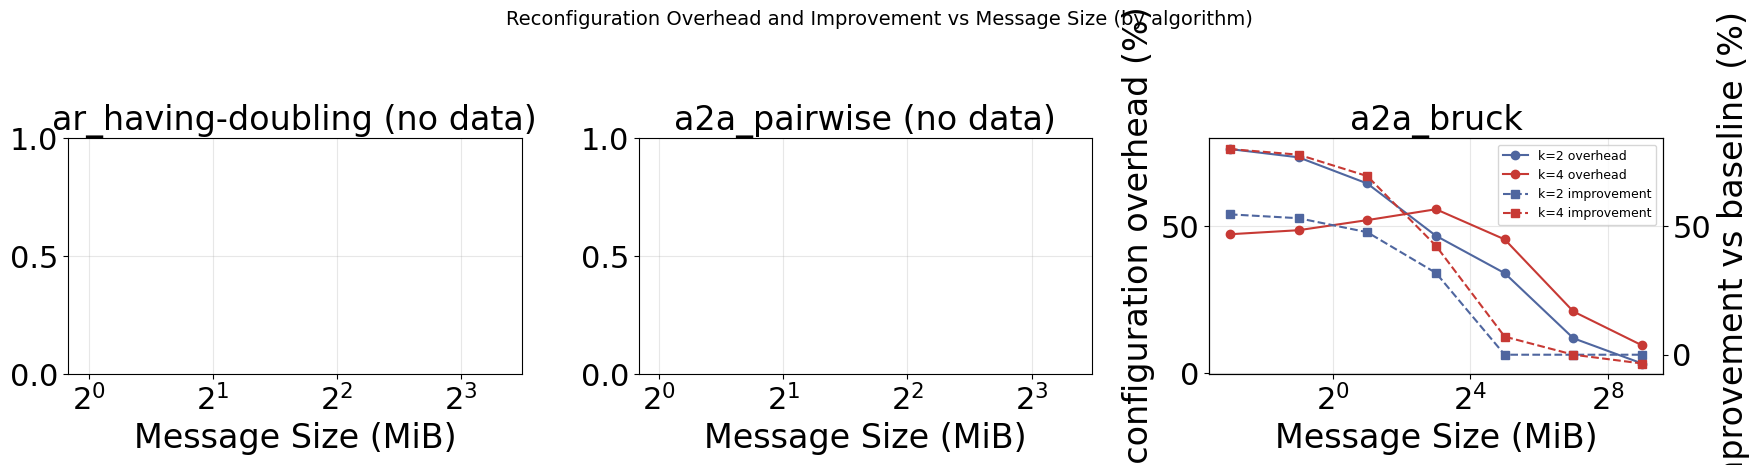

In [51]:
algs = ['ar_having-doubling', 'a2a_pairwise', 'a2a_bruck']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
for ax, alg_name in zip(axes, algs):
    subdf = df[df["algorithm"] == alg_name].copy()
    subdf = subdf[subdf["status"] == "success"].copy()
    if subdf.empty:
        ax.set_title(f"{alg_name} (no data)")
        ax.set_xlabel('Message Size (MiB)')
        ax.set_xscale('log', base=2)
        ax.grid(alpha=0.3)
        continue

    df_pivot = subdf.pivot_table(
        values=['optimized_cct', 'baseline_cct', 'ideal_cct'],
        index=['message_mib', 'k', 'p'],
        aggfunc='first'
    ).reset_index()

    df_pivot['overhead_pct'] = ((df_pivot['optimized_cct'] - df_pivot['ideal_cct']) / df_pivot['optimized_cct']) * 100
    df_pivot['improvement_pct'] = ((df_pivot['baseline_cct'] - df_pivot['optimized_cct']) / df_pivot['baseline_cct']) * 100

    unique_k = sorted(df_pivot['k'].unique())
    # left y: overhead
    for i, k_val in enumerate(unique_k):
        grp = df_pivot[df_pivot['k'] == k_val].sort_values('message_mib')
        ax.plot(grp['message_mib'], grp['overhead_pct'],
                marker='o', linestyle='-', color=colors[i % len(colors)],
                label=f'k={k_val} overhead')

    ax.set_xlabel('Message Size (MiB)')
    ax.set_xscale('log', base=2)
    ax.set_ylabel('Reconfiguration overhead (%)')
    ax.grid(True, alpha=0.3)

    # right y: improvement
    ax2 = ax.twinx()
    for i, k_val in enumerate(unique_k):
        grp = df_pivot[df_pivot['k'] == k_val].sort_values('message_mib')
        ax2.plot(grp['message_mib'], grp['improvement_pct'],
                 marker='s', linestyle='--', color=colors[i % len(colors)],
                 label=f'k={k_val} improvement')

    ax2.set_ylabel('Improvement vs baseline (%)')

    # legend merge
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='best', fontsize=9)
    ax.set_title(alg_name)

plt.suptitle('Reconfiguration Overhead and Improvement vs Message Size (by algorithm)', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('figures/overhead_improvement_vs_msgsize_by_algo.pdf', bbox_inches='tight')
plt.show()


## 实验2.2：不同重构时延对方案(作用于DV)的影响